In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sn

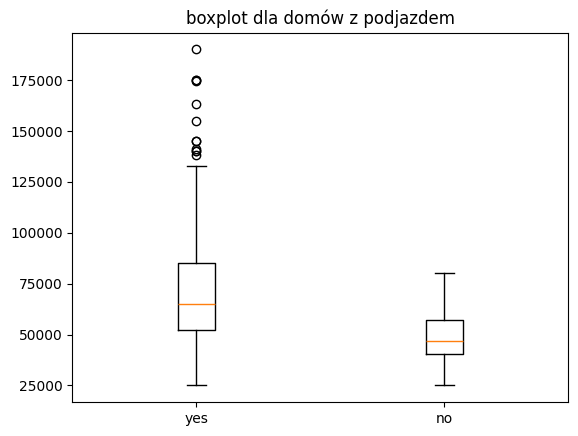

In [2]:
sciezka = 'C:/Users/maja2/Downloads/HousePrices.csv'
dane = pd.read_csv(sciezka)
dane.info
ceny = dane['price'].sort_values().values

grupa1 = dane[dane['driveway'] == "yes"]['price']
grupa2 = dane[dane['driveway'] == "no"]['price']
all_data = [grupa1,grupa2]

plt.boxplot(all_data,labels = ['yes','no'])
plt.title('boxplot dla domów z podjazdem')
plt.show()

In [9]:
def srednia_ucinana(X):
    
    n = len(X)
    spis = []
    for k in range(0, n//2 + 1):
        X_ucinana = np.sum(X[k:n - k])/(n - 2*k)
        spis.append(X_ucinana)
    return spis

sr = [1,7,3,4,8,5,9]

In [10]:
def srednia_winsorowska(X):
    
    n = len(X)
    spis = []
    for k in range(0, n//2 + 1):  
        X_winsor = ((k+1) * X[k] + np.sum(X[k+1:n-k-1]) + (k+1) * X[n-k-1])/n
        spis.append(X_winsor)
    return spis

C:\Users\lab\AppData\Local\Temp\ipykernel_3440\3466051104.py:6: RuntimeWarning: invalid value encountered in scalar divide
  X_ucinana = np.sum(X[k:n - k])/(n - 2*k)


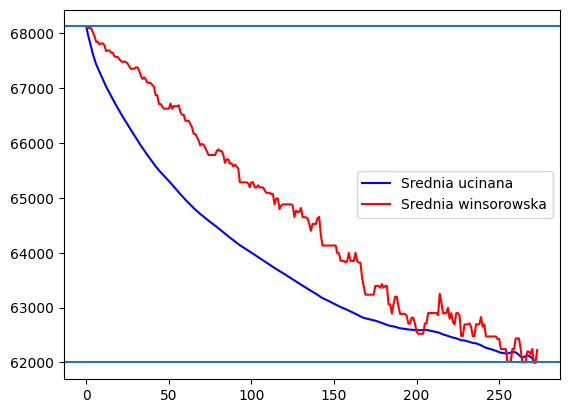

In [55]:
plt.plot(range(0, len(ceny)//2 +1), srednia_ucinana(ceny), 'b', label='Srednia ucinana')
plt.plot(range(0, len(ceny)//2 + 1), srednia_winsorowska(ceny), 'r', label='Srednia winsorowska')
plt.legend()
plt.axhline(y=np.mean(ceny))
plt.axhline(y=np.median(ceny))
plt.show()

In [4]:
x = np.random.normal(10, 5, 1000)
print(np.mean(x), np.median(x), scipy.stats.iqr(x, interpolation='midpoint'), np.var(x), np.sqrt(np.var(x)), scipy.stats.kurtosis(x), scipy.stats.skew(x))
y = np.append(x,np.random.uniform(50, 100, 10))
print(np.mean(y), np.median(y), scipy.stats.iqr(y, interpolation='midpoint'), np.var(y), np.sqrt(np.var(y)), scipy.stats.kurtosis(y), scipy.stats.skew(y))

9.922201357784747 9.897770457077659 6.906029307775556 24.889353186244342 4.988923048739512 -0.008163412702330675 0.05877337845768674
10.61151171830685 9.928303852276365 6.921831288142146 73.67966414994379 8.583685930294967 46.32041021615394 5.5473829906069865


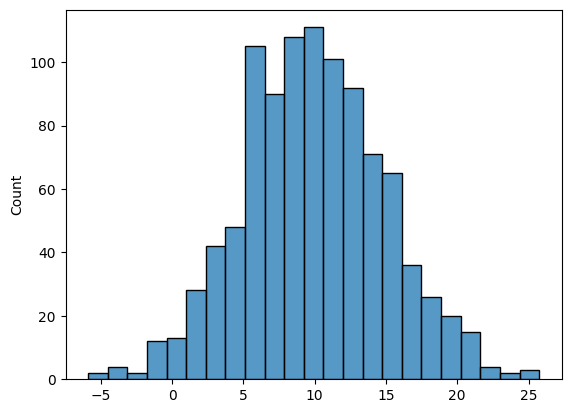

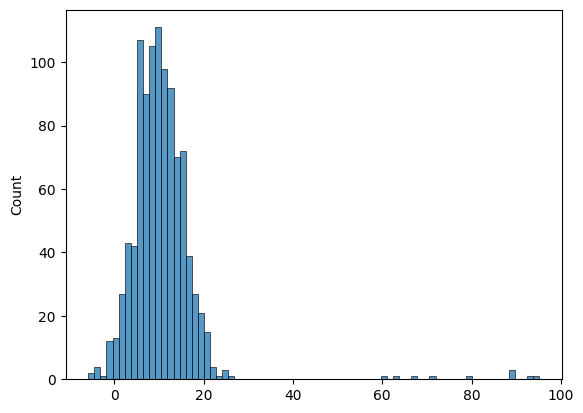

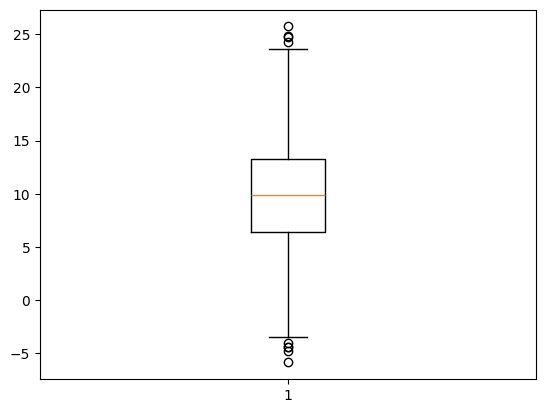

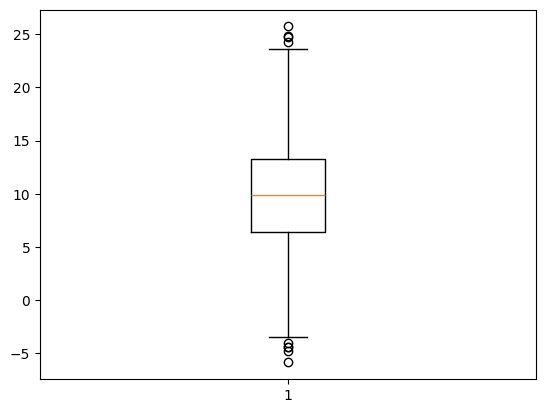

In [7]:
sn.histplot(x)
plt.show()
sn.histplot(y)
plt.show()
plt.boxplot(x)
plt.show()
plt.boxplot(x)
plt.show()


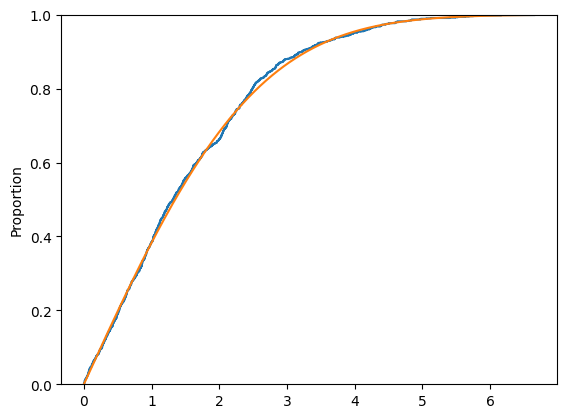

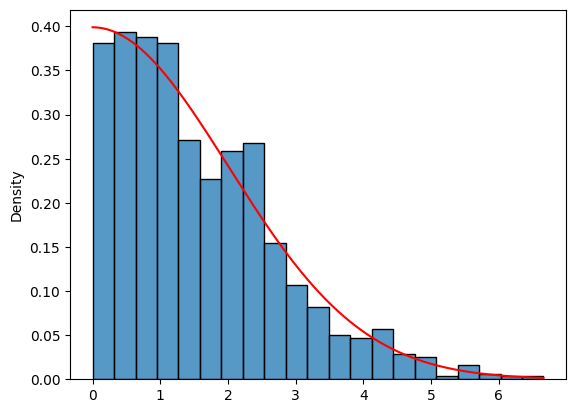

1.5957691216057308 1.584835083137364


In [19]:
sigma = 2
miu = 2
n = 1000

X = np.random.normal(miu, sigma, n)
Y = abs(X - miu)
x_arg = np.linspace(0, max(Y), 1000)
sn.ecdfplot(Y)
plt.plot(x_arg, scipy.stats.norm.cdf(miu + x_arg, sigma, miu) - scipy.stats.norm.cdf(miu - x_arg, sigma, miu))
plt.show()
f = 2 / np.sqrt(2 * np.pi * sigma**2) * np.exp(-1/2 * (-x_arg/sigma)**2)
sn.histplot(Y, stat='density')
plt.plot(x_arg, scipy.stats.norm.pdf(miu + x_arg, sigma, miu) + scipy.stats.norm.pdf(miu - x_arg, sigma, miu), 'r')
plt.show()

EY = 2 * sigma / np.sqrt(2*np.pi)
Y_average = np.mean(Y)
print(EY, Y_average)

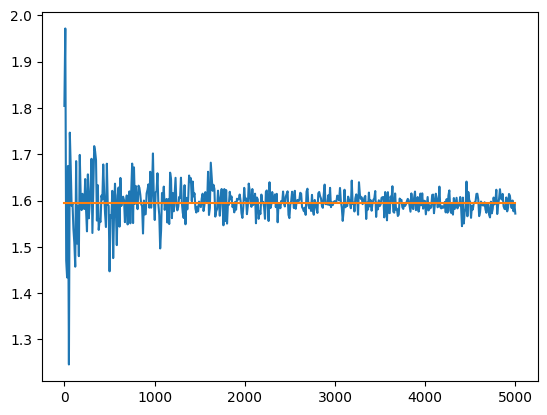

In [28]:
d_ = []
EY = 2 * sigma / np.sqrt(2*np.pi)
for n in range(10, 5001, 10):
    X = np.random.normal(sigma, miu, n)
    d = 1 / n * np.sum(abs(X - np.mean(X)))
    d_.append(d)
plt.plot(np.linspace(0, 5000, 500), d_)
plt.plot(np.linspace(0, 5000, 500), [EY for i in range(500)])
plt.show()